Setup

In [1]:
import matplotlib.pyplot as plt
import pandas as pd
import matplotlib.pyplot as plt
from tqdm import tqdm
import os
import numpy as np
import pandas as pd
from pathlib import Path
import sys
import re

sys.path.append(os.path.join(Path.cwd(), "VTFW_Lab3"))

from VTFW_Lab3.data.data_writer import get_data_dir
from VTFW_Lab3.data.data_writer import get_data_dir, write_flying_wing
from VTFW_Lab3.geometry.naca_airfoil import NACA4, NACA5
from VTFW_Lab3.geometry.generators import get_wing_geometries
from VTFW_Lab3.data.data_classes import FlyingWing
from VTFW_Lab3.data.data_reader import read_flying_wing, read_list_of_flying_wings
from VTFW_Lab3.simulation.alpha_epsilon_simulation import alpha_epsilon_simulation
from VTFW_Lab3.utils.common import find_simulation
from VTFW_Lab3.analysis.cg_boundary_analysis import cg_boundary_analysis
from VTFW_Lab3.utils.common import find_analysis
from VTFW_Lab3.geometry.wing_geometry import get_trapezoidal_aspect_ratio, get_taper_ratio, get_sweep_angle


# Initialise data directory for data storage 

data_dir_name = f"Bachelor_Thesis_Data_Dir_Version_Cambered_Foils"
simulation_id = "bat_simu_1"
analysis_id = "bat_analysis_3"

data_dir = get_data_dir(data_dir_name, os.path.join(Path.cwd(), "data"))

os.startfile(data_dir)

Wing geometries

In [2]:
taper_ratios  = np.round(np.linspace(0.2, 1.0, 5), 3)
aspect_ratios = np.round(np.linspace(4, 12, 5), 3)
sweep_angles  = np.round(np.linspace(0, 40, 5), 3)

print(taper_ratios)
print(aspect_ratios)
print(sweep_angles)


airfoils = [NACA4("1315"), NACA4("1415"), NACA4("1515"), NACA4("2315"), NACA4("2415"), NACA4("2515"), NACA4("3315"), NACA4("3415"), NACA4("3515"), NACA4("4315"), NACA4("4415"), NACA4("4515")]

wing_geometries = get_wing_geometries(taper_ratios, aspect_ratios, sweep_angles, airfoils)
flying_wings = read_list_of_flying_wings(data_dir)

# Create new flying wings if they do not exsits in data directory
for wing_geo in wing_geometries:
    if not any(wing_geo.id in flying_wing.id for flying_wing in flying_wings):
        new_flying_wing = FlyingWing(f"{wing_geo.id}", wing_geo, [])
        write_flying_wing(data_dir, new_flying_wing)


[0.2 0.4 0.6 0.8 1. ]
[ 4.  6.  8. 10. 12.]
[ 0. 10. 20. 30. 40.]


Simulation

In [3]:
alpha_vals = np.linspace(0, 10, 11)
twist_vals = np.linspace(-5, 5, 11)

flying_wings = read_list_of_flying_wings(data_dir)
flying_wings = list(filter(lambda flying_wing: find_simulation(flying_wing, simulation_id) is None, flying_wings))

for flying_wing in tqdm(flying_wings, desc="Processing simulations", unit="iteration"):
    simu = alpha_epsilon_simulation(flying_wing, simulation_id, alpha_vals, twist_vals, 100)
    flying_wing.simulations.append(simu)
    write_flying_wing(data_dir, flying_wing)


Processing simulations: 0iteration [00:00, ?iteration/s]


Analysis

In [4]:
flying_wings = read_list_of_flying_wings(data_dir)
flying_wings = list(filter(lambda flying_wing: not find_simulation(flying_wing, simulation_id) is None and find_analysis(flying_wing, analysis_id) is None, flying_wings))

for flying_wing in tqdm(flying_wings, desc="Processing analysis", unit="iteration"):
    simu = find_simulation(flying_wing, simulation_id)
    analysis = cg_boundary_analysis(flying_wing, simulation_id, new_analysis_id= analysis_id)
    write_flying_wing(data_dir, flying_wing)

Processing analysis: 100%|██████████| 1500/1500 [04:06<00:00,  6.09iteration/s]


Result

Numbers

In [5]:
flying_wings = read_list_of_flying_wings(data_dir)
flying_wings = list(filter(lambda flying_wing: not (find_analysis(flying_wing, analysis_id) is None), flying_wings))
rows = []

for flying_wing in tqdm(flying_wings, desc="Processing results", unit="iteration"):
    wing_geometry = flying_wing.wing_geometry

    delta_cg = find_analysis(flying_wing, analysis_id).cg_delta
    cg_pos = find_analysis(flying_wing, analysis_id).cg_min + find_analysis(flying_wing, analysis_id).cg_delta/2

    
    if 0 < cg_pos and cg_pos < max([wing_geometry.leading_edge(wing_geometry.half_span)[0] + wing_geometry.chord_len(wing_geometry.half_span), wing_geometry.chord_len(0)]):
        cg_in_plane = True
    
    if not cg_in_plane:
        print("Warning CG is not in plane")

    row ={
        "sweep": get_sweep_angle(wing_geometry),
        "taper ratio": get_taper_ratio(wing_geometry),
        "aspect ratio": get_trapezoidal_aspect_ratio(wing_geometry),
        "airfoil": wing_geometry.airfoil(0).name,
        "cg boundary delta": delta_cg,
        "cg position": cg_pos,
        "cg_in_plane": cg_in_plane
    }

    rows.append(row)
    
df = pd.DataFrame(rows).round(3)

print("Dataframe: ")
print(df)

# Top 3 Best and Worst

df_ranked = df.sort_values("cg boundary delta")
print("Top 3 Best:")
print(df_ranked.tail(3))

print("Top 3 Worst:")
print(df_ranked.head(3))


corr_matrix = df[["sweep", "taper ratio", "aspect ratio"]].corrwith(df["cg boundary delta"])

#df.to_csv(path_or_buf=os.path.join(data_dir, "df.csv"))
print()
print(f"Correlation table for cg boundary delta:")
print(f"{corr_matrix}")
print()




delta_col = "cg boundary delta"
airfoil_col = "airfoil"

# -----------------------------
# Table 1: ΔCG summary statistics
# -----------------------------
cg_stats_per_airfoil = (
    df.groupby(airfoil_col)[delta_col]
    .agg(
        **{
            "min ΔCG": "min",
            "mean ΔCG": "mean",
            "max ΔCG": "max",
        }
    )
    .round(3)
)

total_stats = pd.DataFrame(
    {
        "min ΔCG": [df[delta_col].min()],
        "mean ΔCG": [df[delta_col].mean()],
        "max ΔCG": [df[delta_col].max()],
    },
    index=["All airfoils pooled"]
).round(3)

cg_stats_table = pd.concat([cg_stats_per_airfoil, total_stats])


# -----------------------------
# Table 2: Configuration counts
# -----------------------------
cg_counts_per_airfoil = (
    df.groupby(airfoil_col)[delta_col]
    .agg(
        **{
            "Total configurations": "count",
            "n(ΔCG > 0)": lambda x: (x > 0).sum(),
            "n(ΔCG ≤ 0)": lambda x: (x <= 0).sum(),
        }
    )
)

total_counts = pd.DataFrame(
    {
        "Total configurations": [df[delta_col].count()],
        "n(ΔCG > 0)": [(df[delta_col] > 0).sum()],
        "n(ΔCG ≤ 0)": [(df[delta_col] <= 0).sum()],
    },
    index=["All airfoils"]
)

cg_counts_table = pd.concat([cg_counts_per_airfoil, total_counts])

cg_counts_table["% ΔCG > 0"] = (
    cg_counts_table["n(ΔCG > 0)"]
    / cg_counts_table["Total configurations"]
    * 100
).round(1)


print("Table 1: ΔCG summary statistics by airfoil")
print(cg_stats_table)

print("\nTable 2: Number of configurations by ΔCG sign")
print(cg_counts_table)


Processing results: 100%|██████████| 1500/1500 [00:00<00:00, 44270.80iteration/s]

Dataframe: 
      sweep  taper ratio  aspect ratio   airfoil  cg boundary delta  \
0       0.0          0.2          10.0  naca1315             -0.005   
1       0.0          0.2          10.0  naca1415             -0.008   
2       0.0          0.2          10.0  naca1515             -0.012   
3       0.0          0.2          10.0  naca2315             -0.037   
4       0.0          0.2          10.0  naca2415             -0.044   
...     ...          ...           ...       ...                ...   
1495   40.0          1.0           8.0  naca3415             -0.009   
1496   40.0          1.0           8.0  naca3515             -0.179   
1497   40.0          1.0           8.0  naca4315             -0.037   
1498   40.0          1.0           8.0  naca4415             -0.125   
1499   40.0          1.0           8.0  naca4515             -0.183   

      cg position  cg_in_plane  
0           0.278         True  
1           0.284         True  
2           0.290         True  
3  

Plots

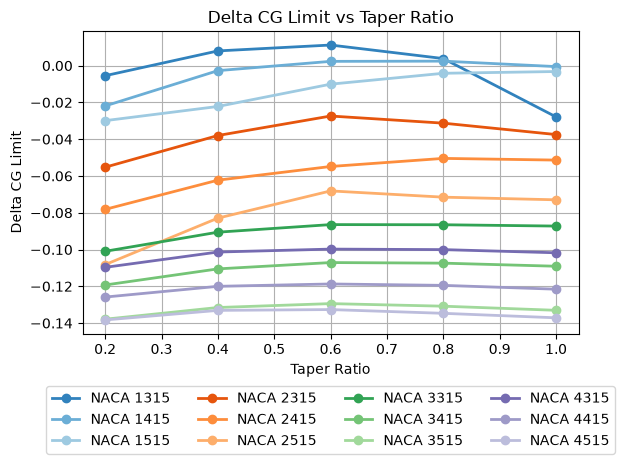

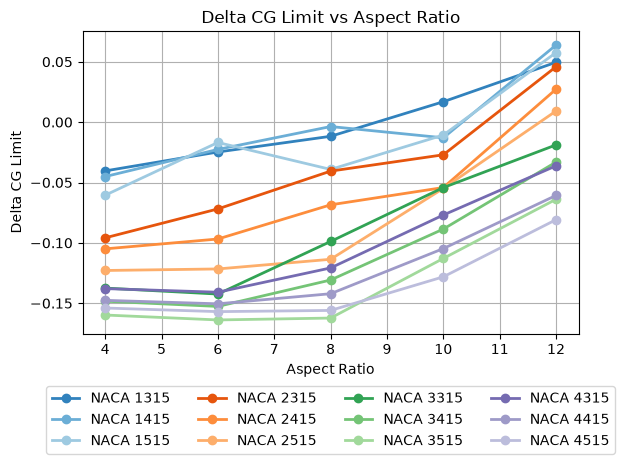

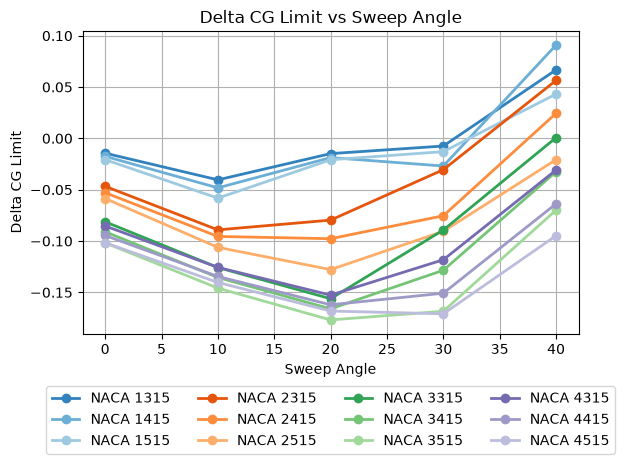

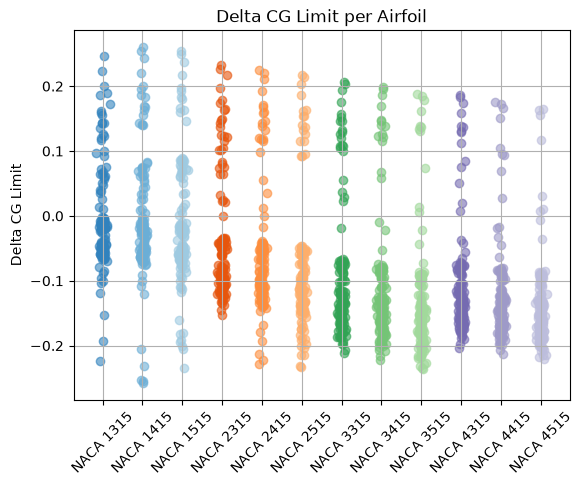

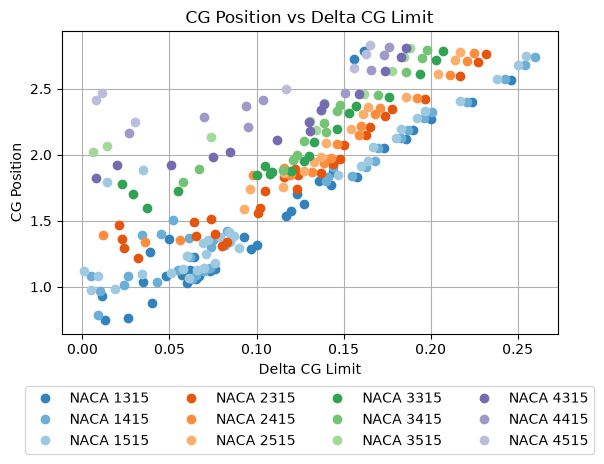

In [6]:
# ====================================================
# SETTINGS
# ====================================================
np.random.seed(42)
plot_avg = True




def format_airfoil(text):
    match = re.fullmatch(r"([A-Za-z]+)(\d+)", text.strip())

    if match:
        letters, numbers = match.groups()
        return f"{letters.upper()} {numbers}"

    return text

# ====================================================
# 0. COLORMAP
# ====================================================

airfoils = df["airfoil"].unique()

cmap = plt.get_cmap("tab20c")

airfoil_colors = dict()

for i, airfoil in  enumerate(airfoils):
    airfoil_colors[airfoil] = cmap(i + int(airfoil[4]) - 1)


# ====================================================
# 1. TAPER RATIO PLOT
# ====================================================

plt.figure()

df_t = df.sort_values("taper ratio")

if plot_avg:

    # average over same airfoil + taper ratio
    avg_df = (df_t.groupby(["airfoil", "taper ratio"])["cg boundary delta"].mean().reset_index())

    for airfoil, group in avg_df.groupby("airfoil"):
        jitter = np.random.normal(0, 0.000, size=len(group))

        group = group.sort_values("taper ratio")

        plt.plot(group["taper ratio"], group["cg boundary delta"] + jitter, "-o", label=format_airfoil(airfoil), color=airfoil_colors[airfoil], linewidth=2)

else:

    for (airfoil, ar, sweep), group in df_t.groupby(["airfoil", "aspect ratio", "sweep"]):

        group = group.sort_values("taper ratio")

        plt.plot(group["taper ratio"], group["cg boundary delta"], "-o", color=airfoil_colors[airfoil], alpha=0.7)


plt.title("Delta CG Limit vs Taper Ratio")
plt.xlabel("Taper Ratio")
plt.ylabel("Delta CG Limit")
plt.grid(True)
plt.legend(loc="upper center",bbox_to_anchor=(0.5, -0.15),ncol=4)
plt.subplots_adjust(bottom=0.25)

# ====================================================
# 2. ASPECT RATIO PLOT
# ====================================================

plt.figure()

df_ar = df.sort_values("aspect ratio")

if plot_avg:

    avg_df = (df_ar.groupby(["airfoil", "aspect ratio"])["cg boundary delta"].mean().reset_index())

    for airfoil, group in avg_df.groupby("airfoil"):
        jitter = np.random.normal(0, 0.00, size=len(group))
        group = group.sort_values("aspect ratio")

        plt.plot(group["aspect ratio"], group["cg boundary delta"] + jitter, "-o", label=format_airfoil(airfoil), color=airfoil_colors[airfoil], linewidth=2)

else:

    for (airfoil, taper, sweep), group in df_ar.groupby(["airfoil", "taper ratio", "sweep"]):

        group = group.sort_values("aspect ratio")

        plt.plot(group["aspect ratio"], group["cg boundary delta"], "-o", color=airfoil_colors[airfoil], alpha=0.7)

plt.title("Delta CG Limit vs Aspect Ratio")

plt.xlabel("Aspect Ratio")
plt.ylabel("Delta CG Limit")
plt.grid(True)
plt.legend(loc="upper center",bbox_to_anchor=(0.5, -0.15),ncol=4)
plt.subplots_adjust(bottom=0.25)
plt.show()

# ====================================================
# 3. SWEEP PLOT
# ====================================================

plt.figure()

df_s = df.sort_values("sweep")

if plot_avg:

    avg_df = (df_s.groupby(["airfoil", "sweep"])["cg boundary delta"].mean().reset_index())

    for airfoil, group in avg_df.groupby("airfoil"):
        jitter = np.random.normal(0, 0.00, size=len(group))
        group = group.sort_values("sweep")

        plt.plot(group["sweep"], group["cg boundary delta"] + jitter, "-o", label=format_airfoil(airfoil), color=airfoil_colors[airfoil], linewidth=2)

else:

    for (airfoil, taper, ar), group in df_s.groupby(["airfoil", "taper ratio", "aspect ratio"]):

        group = group.sort_values("sweep")

        plt.plot(group["sweep"], group["cg boundary delta"], "-o", color=airfoil_colors[airfoil], alpha=0.7)

plt.title("Delta CG Limit vs Sweep Angle")
plt.xlabel("Sweep Angle")
plt.ylabel("Delta CG Limit")
plt.grid(True)
plt.legend(loc="upper center",bbox_to_anchor=(0.5, -0.15),ncol=4)
plt.subplots_adjust(bottom=0.25)
plt.show()
# ====================================================
# 4. AIRFOIL PLOT
# ====================================================
plt.figure()


airfoils = df["airfoil"].unique()

for i, airfoil in enumerate(airfoils):

    df_airfoil = df[df["airfoil"] == airfoil]
    x_vals = np.random.normal(loc=i, scale=0.05, size=len(df_airfoil))
    plt.scatter(x_vals, df_airfoil["cg boundary delta"], alpha=0.6, color=airfoil_colors[airfoil])

formatted_airfoils = [format_airfoil(airfoil) for airfoil in airfoils]
plt.xticks(range(len(airfoils)), formatted_airfoils, rotation=45)
plt.title("Delta CG Limit per Airfoil")
plt.ylabel("Delta CG Limit")
plt.grid(True)


# ====================================================
# 5. CG POSITION VS DELTA CG (AVERAGED)
# ====================================================

plt.figure()
df_pos = df[df["cg boundary delta"]> 0]
avg_df = (df_pos.groupby(["airfoil", "cg boundary delta"])["cg position"].mean().reset_index())

for airfoil, group in avg_df.groupby("airfoil"):

    group = group.sort_values("cg boundary delta")

    jitter = np.random.normal(0, 0.0, size=len(group))

    plt.plot(group["cg boundary delta"],group["cg position"] + jitter,"o",color=airfoil_colors[airfoil],linewidth=2,label=format_airfoil(airfoil))

plt.title("CG Position vs Delta CG Limit")
plt.xlabel("Delta CG Limit")
plt.ylabel("CG Position")
plt.grid(True)
plt.legend(loc="upper center",bbox_to_anchor=(0.5, -0.15),ncol=4)
plt.subplots_adjust(bottom=0.25)


plt.show()